In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization

from tensorflow.keras.utils import set_random_seed

In [15]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (569, 30)
Target Shape: (569,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
set_random_seed(42)

In [19]:
model1 = Sequential([

    Dense(256, activation='relu', input_shape=(30,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

c:\Users\X280\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model2 = Sequential([

    Dense(256, activation='relu', input_shape=(30,)),
    Dropout(0.2),

    Dense(128, activation='relu'),
    Dropout(0.2),

    Dense(64, activation='relu'),

    Dense(1, activation='sigmoid')
])

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

In [21]:
model3 = Sequential([

    Dense(256, activation='relu', input_shape=(30,)),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(64, activation='relu'),

    Dense(1, activation='sigmoid')
])

model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

In [22]:
model4 = Sequential([

    Dense(256, activation='relu', input_shape=(30,)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu'),

    Dense(1, activation='sigmoid')
])

model4.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history4 = model4.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

In [23]:
model4 = Sequential([

    Dense(256, activation='relu', input_shape=(30,)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu'),

    Dense(1, activation='sigmoid')
])

model4.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history4 = model4.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

In [26]:
model5 = Sequential([

    Dense(256, activation='relu', input_shape=(30,)),
    BatchNormalization(),

    Dense(128, activation='relu'),
    BatchNormalization(),

    Dense(64, activation='relu'),

    Dense(1, activation='sigmoid')
])

model5.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history5 = model5.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

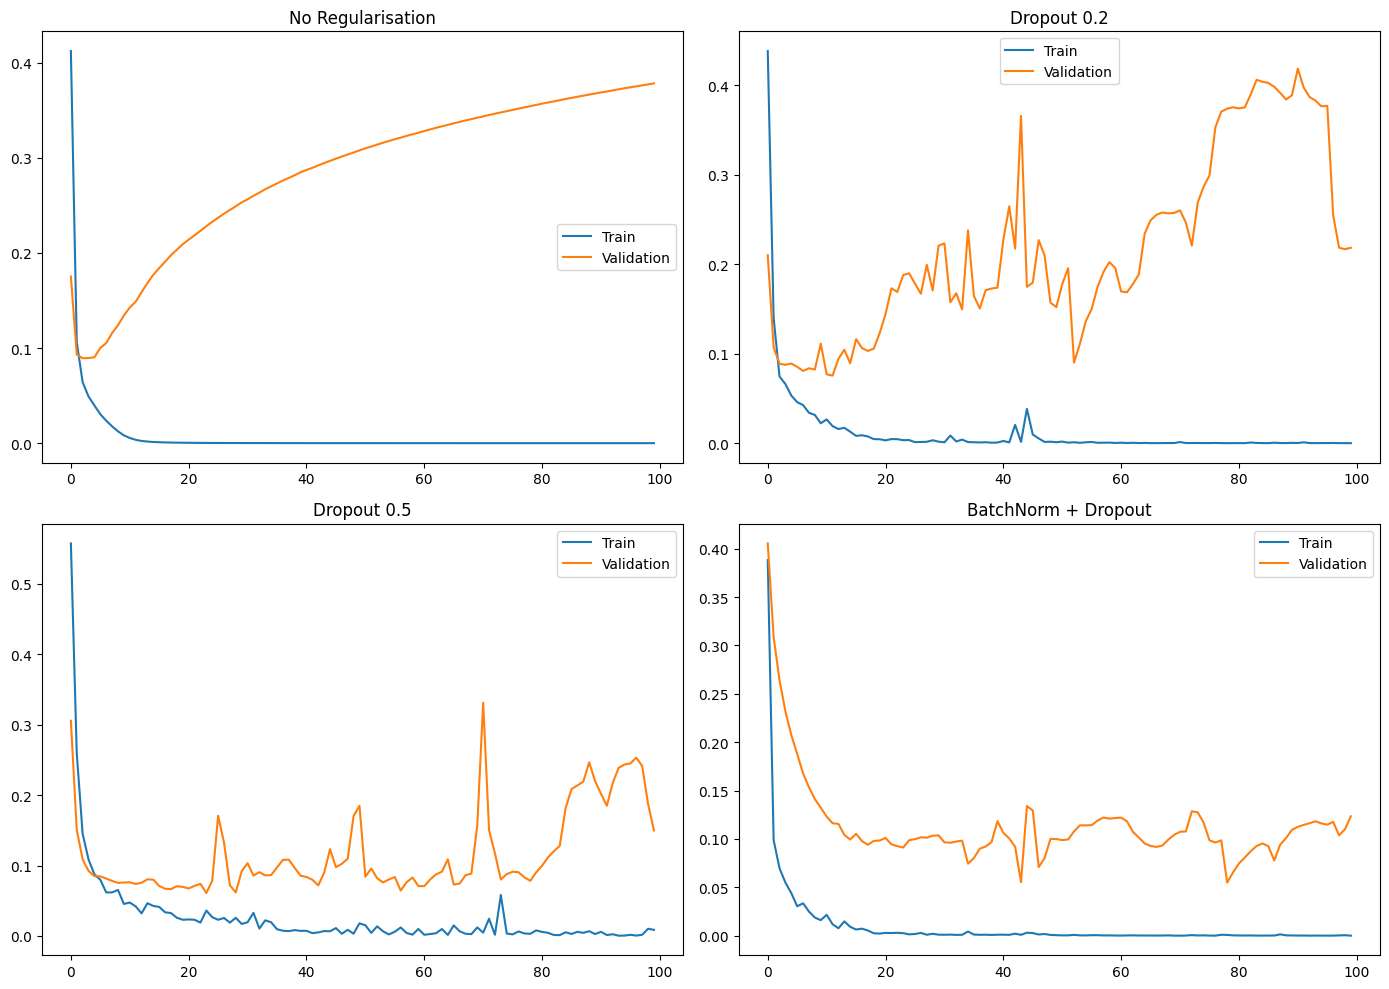

In [27]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,10)
)

models = [

    ("No Regularisation", history1),

    ("Dropout 0.2", history2),

    ("Dropout 0.5", history3),

    ("BatchNorm + Dropout", history4)
]

for ax, (title, history) in zip(
        axes.flatten(),
        models):

    ax.plot(
        history.history['loss'],
        label='Train'
    )

    ax.plot(
        history.history['val_loss'],
        label='Validation'
    )

    ax.set_title(title)

    ax.legend()

plt.tight_layout()

plt.show()

In [28]:
results = []

all_models = [

    ("No Regularisation", model1, history1),

    ("Dropout 0.2", model2, history2),

    ("Dropout 0.5", model3, history3),

    ("BatchNorm Only", model5, history5),

    ("BatchNorm + Dropout", model4, history4)
]

for name, model, history in all_models:

    loss, accuracy = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    results.append([

        name,

        round(accuracy,4),

        round(
            min(history.history['val_loss']),
            4
        )
    ])

In [29]:
summary = pd.DataFrame(

    results,

    columns=[

        "Configuration",

        "Test Accuracy",

        "Best Val Loss"
    ]
)

print(summary)

         Configuration  Test Accuracy  Best Val Loss
0    No Regularisation         0.9737         0.0893
1          Dropout 0.2         0.9561         0.0755
2          Dropout 0.5         0.9825         0.0610
3       BatchNorm Only         0.9561         0.0979
4  BatchNorm + Dropout         0.9561         0.0549
